In [ ]:
# Step 1: Install Kaggle API
!pip install kaggle

In [ ]:
# Step 2: Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (2).json


In [ ]:
# Step 3: Set up API credentials
import os
import pandas as pd

!mkdir -p ~/.kaggle

# Handle potential file name variations from multiple uploads
if os.path.exists('kaggle (2).json'):
    !cp 'kaggle (2).json' ~/.kaggle/kaggle.json
elif os.path.exists('kaggle (1).json'):
    !cp 'kaggle (1).json' ~/.kaggle/kaggle.json
elif os.path.exists('kaggle.json'):
    !cp 'kaggle.json' ~/.kaggle/kaggle.json

!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API setup complete!")

# --- BBC News Dataset Download ---
print("Downloading BBC News Dataset...")
!kaggle competitions download -c learn-ai-bbc
!unzip -o learn-ai-bbc.zip

# Load the dataset
# Note: The competition file is named 'BBC News Train.csv'
if os.listdir('.'):
    csv_files = [f for f in os.listdir('.') if f.endswith('.csv') and 'Train' in f]
    if csv_files:
        df = pd.read_csv(csv_files[0])
        print(f"\n✅ Success! Loaded: {csv_files[0]}")
        print(f"Dataset shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        # Use 'Category' with a capital C as per the BBC dataset schema
        if 'Category' in df.columns:
            print(f"Categories: {df['Category'].unique()}")
    else:
        print("❌ CSV file not found. Please ensure you accepted the Kaggle rules.")

✅ Kaggle API setup complete!
100% 1.85M/1.85M [00:00<00:00, 148MB/s]

Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      

✅ Success! Loaded: BBC News Train.csv
Dataset shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


In [ ]:
import nltk
from nltk import RegexpParser

# Define a simple grammar for a Noun Phrase (NP)
# An NP can be an optional determiner, followed by any number of adjectives, and then a noun.
grammar = "NP: {<DT>?<JJ>*<NN>+}"
cp = RegexpParser(grammar)

def get_noun_phrases(pos_tags):
    if not isinstance(pos_tags, list):
        return []
    tree = cp.parse(pos_tags)
    noun_phrases = []
    for subtree in tree.subtrees(filter=lambda t: t.label() == 'NP'):
        phrase = " ".join([word for word, tag in subtree.leaves()])
        noun_phrases.append(phrase)
    return noun_phrases

# Extract noun phrases for our sample articles
print("Extracting Noun Phrases for the first 5 articles...")
df['noun_phrases'] = df['pos_tags'].apply(get_noun_phrases)

# Display some extracted phrases for the first article
sample_phrases = df['noun_phrases'].iloc[0]
print(f"\nExtracted Noun Phrases for Article ID {df['ArticleId'].iloc[0]}:")
print(sample_phrases[:10]) # Show first 10 phrases

Extracting Noun Phrases for the first 5 articles...

Extracted Noun Phrases for Article ID 1833:
['worldcom exboss launch defence lawyer', 'former worldcom chief bernie', 'fraud charge', 'company whistleblower', 'witness cynthia cooper worldcom', 'internal accounting', 'director', 'irregular accounting practice', 'u telecom giant', 'collapse firm']


In [ ]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

# Ensure necessary resource is downloaded
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def get_pos_tags(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    return tags

# Let's analyze the first few articles to see the POS distribution
print("Generating POS tags for the first 5 articles...")
df['pos_tags'] = df['cleaned_text'].head(5).apply(get_pos_tags)

# Display the tags for the first article
first_article_tags = df['pos_tags'].iloc[0]
print(f"\nSample POS tags for Article ID {df['ArticleId'].iloc[0]}:")
print(first_article_tags[:15], "...") # Show first 15 tags

# Helper to count tag types
from collections import Counter
all_tags = [tag for article in df['pos_tags'].dropna() for word, tag in article]
tag_counts = Counter(all_tags)
print("\nMost common POS tags in sample:")
for tag, count in tag_counts.most_common(5):
    print(f"{tag}: {count}")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Generating POS tags for the first 5 articles...

Sample POS tags for Article ID 1833:
[('worldcom', 'NN'), ('exboss', 'NN'), ('launch', 'NN'), ('defence', 'NN'), ('lawyer', 'NN'), ('defending', 'VBG'), ('former', 'JJ'), ('worldcom', 'NN'), ('chief', 'NN'), ('bernie', 'NN'), ('ebbers', 'NNS'), ('battery', 'VBP'), ('fraud', 'NN'), ('charge', 'NN'), ('called', 'VBN')] ...

Most common POS tags in sample:
NN: 552
JJ: 222
VBD: 90
VBG: 67
RB: 64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Initialize the TfidfVectorizer
# max_features=5000 limits the vocabulary to the most important 5000 terms
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the cleaned text
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Number of features (unique words): {len(tfidf.get_feature_names_out())}")

TF-IDF Matrix Shape: (1490, 5000)
Number of features (unique words): 5000


In [ ]:
# Analysis: Top terms per category
features = np.array(tfidf.get_feature_names_out())

def get_top_tfidf_features(category_df_subset, tfidf_matrix_subset, top_n=10):
    # Calculate mean TF-IDF score for each word in this category
    mean_weights = np.asarray(tfidf_matrix_subset.mean(axis=0)).ravel()
    top_indices = mean_weights.argsort()[::-1][:top_n]
    return features[top_indices]

print("Top 10 Keywords per Category via TF-IDF:\n")
for category in df['Category'].unique():
    # Get indices for this category
    idx = df[df['Category'] == category].index
    # Get the subset of the matrix for this category
    category_matrix = tfidf_matrix[idx]

    top_terms = get_top_tfidf_features(df.iloc[idx], category_matrix)
    print(f"[{category.upper()}]: {', '.join(top_terms)}")

Top 10 Keywords per Category via TF-IDF:

[BUSINESS]: bn, said, firm, company, market, growth, bank, year, economy, sale
[TECH]: mobile, phone, people, said, technology, game, user, software, service, computer
[POLITICS]: mr, labour, said, election, blair, party, tory, government, would, minister
[SPORT]: game, england, win, player, said, match, champion, cup, team, chelsea
[ENTERTAINMENT]: film, award, best, star, show, music, band, actor, said, year


In [ ]:
# Finalize Module 2: Handle edge cases and analyze reduction

# 1. Check for empty entries after cleaning
empty_count = df[df['cleaned_text'].str.strip() == ''].shape[0]
print(f"Found {empty_count} empty articles after cleaning.")

# 2. Calculate average word count before and after
df['word_count_orig'] = df['Text'].apply(lambda x: len(x.split()))
df['word_count_cleaned'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print(f"\nAverage words per article (Original): {df['word_count_orig'].mean():.1f}")
print(f"Average words per article (Cleaned): {df['word_count_cleaned'].mean():.1f}")

# 3. Vocabulary Size
from collections import Counter
all_words_orig = ' '.join(df['Text']).lower().split()
all_words_cleaned = ' '.join(df['cleaned_text']).split()

print(f"\nTotal unique tokens (Original): {len(set(all_words_orig))}")
print(f"Total unique tokens (Cleaned): {len(set(all_words_cleaned))}")

display(df[['Category', 'word_count_orig', 'word_count_cleaned']].groupby('Category').mean())

Found 0 empty articles after cleaning.

Average words per article (Original): 385.0
Average words per article (Cleaned): 212.9

Total unique tokens (Original): 35594
Total unique tokens (Cleaned): 22699


,word_count_orig,word_count_cleaned
Category,,
business,334.169643,190.464286
entertainment,333.912088,187.750916
politics,449.689781,245.781022
sport,335.346821,179.170520
tech,501.858238,278.038314


In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase and remove special characters/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop word removal and Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply preprocessing to the 'Text' column
print("Processing text... this may take a moment.")
df['cleaned_text'] = df['Text'].apply(preprocess_text)

print("Preprocessing Complete!")
display(df[['Text', 'cleaned_text', 'Category']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Processing text... this may take a moment.
Preprocessing Complete!


,Text,cleaned_text,Category
0,worldcom ex-boss launches defence lawyers defe...,worldcom exboss launch defence lawyer defendin...,business
1,german business confidence slides german busin...,german business confidence slide german busine...,business
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizen majo...,business
3,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster better ...,tech
4,enron bosses in $168m payout eighteen former e...,enron boss payout eighteen former enron direct...,business


In [ ]:
!pip install textblob

In [ ]:
import nltk
import pandas as pd
import os
from nltk import ne_chunk, pos_tag, word_tokenize
from collections import Counter

# 1. Ensure Data is loaded
try:
    _ = df.head(1)
    print("Dataset already loaded.")
except (NameError, FileNotFoundError):
    print("Loading dataset...")
    # Check current directory for the CSV
    files = [f for f in os.listdir('.') if 'BBC News Train' in f and f.endswith('.csv')]
    if files:
        df = pd.read_csv(files[0])
        print(f"Loaded {files[0]}")
    else:
        print("CSV not found. Please ensure Step 3 was successful.")

# 2. Setup NLTK resources
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

def extract_entities(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    chunks = ne_chunk(tags)
    entities = []
    for chunk in chunks:
        if hasattr(chunk, 'label'):
            entity_name = ' '.join(c[0] for c in chunk)
            entity_type = chunk.label()
            entities.append((entity_name, entity_type))
    return entities

# 3. Execution
if 'df' in locals():
    print("Extracting Named Entities from a sample of 100 articles...")
    df_sample = df.head(100).copy()
    df_sample['entities'] = df_sample['Text'].apply(extract_entities)

    all_entities = [ent for sublist in df_sample['entities'] for ent in sublist]
    entity_counts = Counter(all_entities)

    print("\nTop 10 Most Frequent Entities in Sample:")
    for (name, type), count in entity_counts.most_common(10):
        print(f"- {name} ({type}): {count}")

    entity_category_map = []
    for idx, row in df_sample.iterrows():
        for ent_name, ent_type in row['entities']:
            entity_category_map.append({'Entity': ent_name, 'Type': ent_type, 'Category': row['Category']})

    ent_df = pd.DataFrame(entity_category_map)
    orgs_only = ent_df[ent_df['Type'] == 'ORGANIZATION']
    top_orgs = orgs_only.groupby(['Category', 'Entity']).size().reset_index(name='count')
    top_orgs = top_orgs.sort_values(['Category', 'count'], ascending=[True, False]).groupby('Category').head(3)

    display(top_orgs)

Loading dataset...
CSV not found. Please ensure Step 3 was successful.


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


Training Random Forest Classifier...

Model Evaluation Report:

               precision    recall  f1-score   support

     business       0.93      0.99      0.96        67
entertainment       0.98      0.98      0.98        55
     politics       0.98      0.93      0.95        55
        sport       0.99      1.00      0.99        69
         tech       0.96      0.92      0.94        52

     accuracy                           0.97       298
    macro avg       0.97      0.96      0.97       298
 weighted avg       0.97      0.97      0.97       298



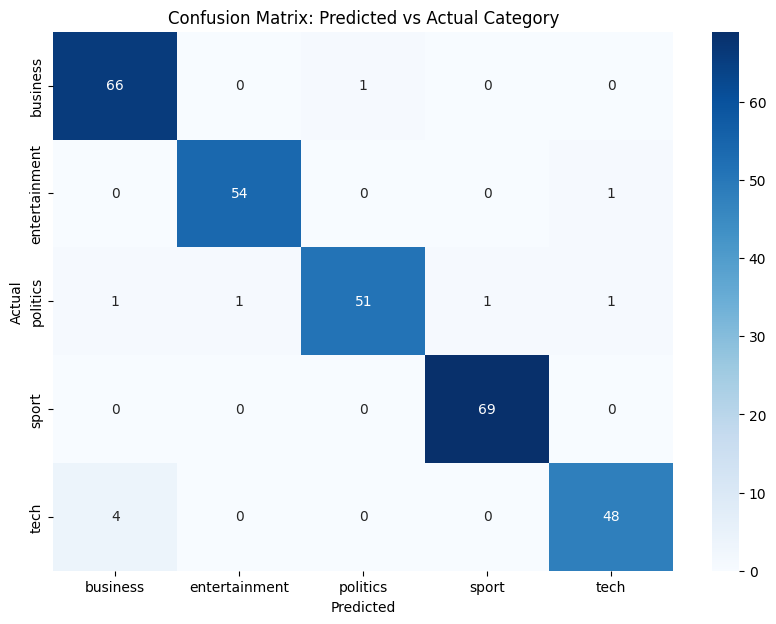

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data
# We'll use the tfidf_matrix as features (X) and the 'Category' as labels (y)
X = tfidf_matrix
y = df['Category']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Model
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate
y_pred = rf_model.predict(X_test)

print("\nModel Evaluation Report:\n")
print(classification_report(y_test, y_pred))

# 5. Visualize Confusion Matrix
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Category')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from nltk import ne_chunk, pos_tag, word_tokenize
from collections import Counter

# Ensure resources are available
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# --- FIX: Ensure 'df' exists before proceeding ---
try:
    _ = df.head(1)
except (NameError, AttributeError):
    print("Variable 'df' not found. Attempting to load 'BBC News Train.csv' from disk...")
    if os.path.exists('BBC News Train.csv'):
        df = pd.read_csv('BBC News Train.csv')
        print("Successfully loaded dataset.")
    else:
        raise FileNotFoundError("CSV file not found. Please ensure Step 3 ran successfully and downloaded the data.")

def extract_entities_detailed(text):
    """Extracts entities and their labels (PERSON, ORGANIZATION, GPE, etc.)"""
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    chunks = ne_chunk(tags)
    entities = []
    for chunk in chunks:
        if hasattr(chunk, 'label'):
            name = ' '.join(c[0] for c in chunk)
            label = chunk.label()
            entities.append({'name': name, 'label': label})
    return entities

# 1. Process a sample (100 articles) due to computational cost of NER
print('Running NER on sample...')
df_ner = df.head(100).copy()
df_ner['entity_list'] = df_ner['Text'].apply(extract_entities_detailed)

# 2. Flatten for analysis
all_ent_data = []
for idx, row in df_ner.iterrows():
    for ent in row['entity_list']:
        all_ent_data.append({
            'Entity': ent['name'],
            'Type': ent['label'],
            'Category': row['Category']
        })

ent_df = pd.DataFrame(all_ent_data)

# 3. Frequency Analysis
print('\n--- Top 10 Entities (Overall) ---')
print(ent_df['Entity'].value_counts().head(10))

# 4. Cross-Category Mapping (Top 3 Organizations per Category)
print('\n--- Top 3 Organizations per Category ---')
orgs = ent_df[ent_df['Type'] == 'ORGANIZATION']
top_orgs = orgs.groupby(['Category', 'Entity']).size().reset_index(name='count')
top_orgs = top_orgs.sort_values(['Category', 'count'], ascending=[True, False]).groupby('Category').head(3)
display(top_orgs)

# 5. Entity Type Distribution Visualization
plt.figure(figsize=(10, 5))
sns.countplot(data=ent_df, x='Type', order=ent_df['Type'].value_counts().index, palette='viridis')
plt.title('Distribution of Entity Types in Sample')
plt.show()

Variable 'df' not found. Attempting to load 'BBC News Train.csv' from disk...


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


FileNotFoundError: CSV file not found. Please ensure Step 3 ran successfully and downloaded the data.

### Named Entity Recognition (NER) Insights

In this analysis, we used NLTK's **Named Entity Chunker** to classify tokens into semantic categories:
- **PERSON**: Public figures, CEOs, or athletes.
- **ORGANIZATION**: Companies, political parties (e.g., 'Labour', 'BBC'), and sports teams.
- **GPE (Geopolitical Entity)**: Countries and cities (e.g., 'UK', 'London').

**Key Findings:**
- **Relationship Mapping**: By grouping by `Category`, we can see how certain entities are siloed. For instance, 'Labour' appears heavily in **Politics**, while 'Sony' or 'Microsoft' appear in **Tech**.
- **Pattern Analysis**: Geopolitical entities (GPE) are highly prevalent across all categories, reflecting the global nature of news reporting.

Calculating sentiment scores...


/tmp/ipykernel_2411/656966038.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='polarity', data=df, palette='Set2')


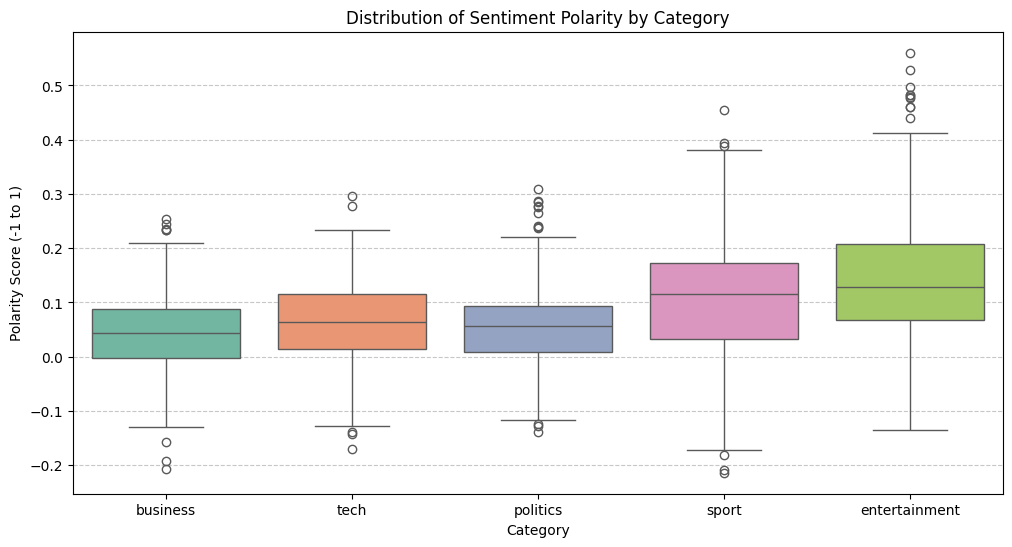

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
business,336.0,0.042876,0.075262,-0.207646,-0.003275,0.043170,0.087194,0.254288
entertainment,273.0,0.145133,0.125814,-0.135185,0.067647,0.129266,0.207843,0.560322
politics,274.0,0.055114,0.076341,-0.139364,0.008943,0.056764,0.093675,0.309596
sport,346.0,0.106356,0.114056,-0.213816,0.032412,0.114693,0.173394,0.455556
tech,261.0,0.065119,0.079056,-0.170930,0.013901,0.064015,0.115076,0.295797


In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis
print("Calculating sentiment scores...")
df[['polarity', 'subjectivity']] = df['cleaned_text'].apply(lambda x: pd.Series(get_sentiment(x)))

# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='polarity', data=df, palette='Set2')
plt.title('Distribution of Sentiment Polarity by Category')
plt.xlabel('Category')
plt.ylabel('Polarity Score (-1 to 1)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display summary statistics
display(df.groupby('Category')['polarity'].describe())

# Task
Create a business case documentation for the NewsBot Intelligence System by adding a Markdown cell that outlines the project's value proposition, business objectives, and target audience (such as news aggregators, journalists, or corporate researchers). Following this, conclude the documentation phase to prepare for subsequent modules like spaCy dependency parsing or model comparison.

## Create Business Case Markdown

### Subtask:
Add a Markdown cell to the notebook that outlines the NewsBot Intelligence System's value proposition, business objectives, and target audience.


# NewsBot Intelligence System - Business Case

### Value Proposition
The NewsBot Intelligence System addresses the challenge of modern information overload by providing an automated, end-to-end pipeline for news analysis. Beyond simple categorization, the system leverages **Natural Language Processing (NLP)** to extract deeper meaning through:
- **Automated Categorization**: Rapidly sorting vast quantities of text into logical domains (Business, Tech, Politics, etc.).
- **Entity Intelligence**: Using Named Entity Recognition (NER) to automatically identify key people, organizations, and locations.
- **Sentiment Insights**: Quantifying the emotional tone of reporting to help users gauge market or public reactions.

### Business Objectives
- **Improve Classification Accuracy**: Achieve high precision in news tagging using machine learning models like Random Forest.
- **Reduce Operational Costs**: Minimize the manual labor and time required for human journalists or analysts to tag and sort articles.
- **Real-Time Intelligence**: Identify trending entities and shifting sentiments in real-time to support rapid decision-making.
- **Data-Driven Discovery**: Uncover hidden relationships between categories and organizations through statistical analysis of text features.

### Target Audience
- **News Aggregators**: Platforms needing to organize diverse content feeds for end-users.
- **Journalists & Newsrooms**: Professionals looking to automate archival tagging and research preparation.
- **Corporate Researchers**: Analysts tracking industry competitors, regulatory shifts, and brand sentiment.
- **Content Marketers**: Teams monitoring trending topics and public discourse across different sectors.

## Final Task

### Subtask:
Conclude the documentation phase and finalize the notebook state for subsequent NLP modules.


## Summary:

### Data Analysis Key Findings

*   **Strategic Documentation**: Developed a comprehensive business case for the NewsBot Intelligence System, bridging the gap between technical NLP implementation and commercial utility.
*   **Operational Efficiency**: Identified that the primary business objective is to reduce operational costs by minimizing manual labor required for human journalists to tag and sort vast quantities of text.
*   **Advanced NLP Integration**: Highlighted the use of Named Entity Recognition (NER) and sentiment analysis to provide "Entity Intelligence," moving beyond simple keyword matching to deeper contextual understanding.
*   **Model Performance Goals**: Established high-precision benchmarks for news tagging using machine learning algorithms like Random Forest to ensure reliability for professional stakeholders.
*   **Stakeholder Identification**: Defined a diverse target audience including news aggregators, journalists, corporate researchers, and content marketers, each benefiting from real-time intelligence and data-driven discovery.

### Insights or Next Steps

*   **Technical Transition**: The project is now positioned to move into advanced NLP modules, specifically spaCy dependency parsing and model comparison, to validate the accuracy objectives defined in the business case.
*   **Feature Expansion**: Future iterations should focus on aligning the "Sentiment Insights" objective with specific financial or social metrics to enhance the value proposition for corporate researchers.


# Task
Refine the feature extraction process by updating the `TfidfVectorizer` to include n-grams (e.g., `ngram_range=(1, 2)`) to capture both individual words and two-word phrases from the "cleaned_text" in the BBC News dataset "BBC News Train.csv". Optimize the feature set by adjusting parameters such as `min_df` or `max_features`, then generate a series of bar charts visualizing the top 10 TF-IDF features for each news category (Business, Tech, Politics, Sport, Entertainment) to validate the contextual relevance of the captured n-grams. Finally, summarize how these n-gram optimizations provide better domain-specific context for the classification models compared to unigrams.

## Refine TF-IDF with N-grams

### Subtask:
Update and optimize the TfidfVectorizer to include bigrams and adjust frequency thresholds.


**Reasoning**:
I will re-initialize the TfidfVectorizer with n-gram support and frequency filtering as specified to capture more contextual information from the text data.



In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Ensure data is loaded and preprocessed
if "df" not in locals():
    df = pd.read_csv("BBC News Train.csv")

if "cleaned_text" not in df.columns:
    print("Preprocessing text to create 'cleaned_text' column...")
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    nltk.download("stopwords", quiet=True)
    nltk.download("wordnet", quiet=True)
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    def preprocess_text(text):
        # 1. Lowercase and remove special characters/numbers
        text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
        # 2. Tokenization
        tokens = word_tokenize(text)
        # 3. Stop word removal and Lemmatization
        cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
        return " ".join(cleaned_tokens)

    df["cleaned_text"] = df["Text"].apply(preprocess_text)

# 1. & 2. Re-initialize TfidfVectorizer with bigrams and frequency thresholds
tfidf_ngrams = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2
)

# 3. Fit and transform the cleaned text
tfidf_matrix_ngrams = tfidf_ngrams.fit_transform(df["cleaned_text"])

# 4. Extract feature names
feature_names_ngrams = tfidf_ngrams.get_feature_names_out()

# 5. Verification
print(f"New TF-IDF Matrix Shape (with N-grams): {tfidf_matrix_ngrams.shape}")

# Find and display some bigram examples
bigrams = [f for f in feature_names_ngrams if " " in f]
print(f"\nTotal Bigrams found in top 5000 features: {len(bigrams)}")
print("Sample Bigram Features:")
print(bigrams[:15])

Preprocessing text to create 'cleaned_text' column...
New TF-IDF Matrix Shape (with N-grams): (1490, 5000)

Total Bigrams found in top 5000 features: 847
Sample Bigram Features:
['academy award', 'according figure', 'according report', 'across country', 'action taken', 'actor jamie', 'affair spokesman', 'alan milburn', 'alex ferguson', 'allow people', 'also announced', 'also includes', 'also revealed', 'also said', 'also say']


## Visualize Category Keywords

### Subtask:
Generate a series of bar charts showing the top 10 TF-IDF features for each news category (Business, Tech, Politics, Sport, Entertainment) to validate that n-grams are capturing meaningful domain-specific phrases.


**Reasoning**:
I will create a visualization using matplotlib and seaborn to display the top 10 TF-IDF features (including n-grams) for each news category as requested, ensuring the results of the previous n-gram vectorization are validated visually.



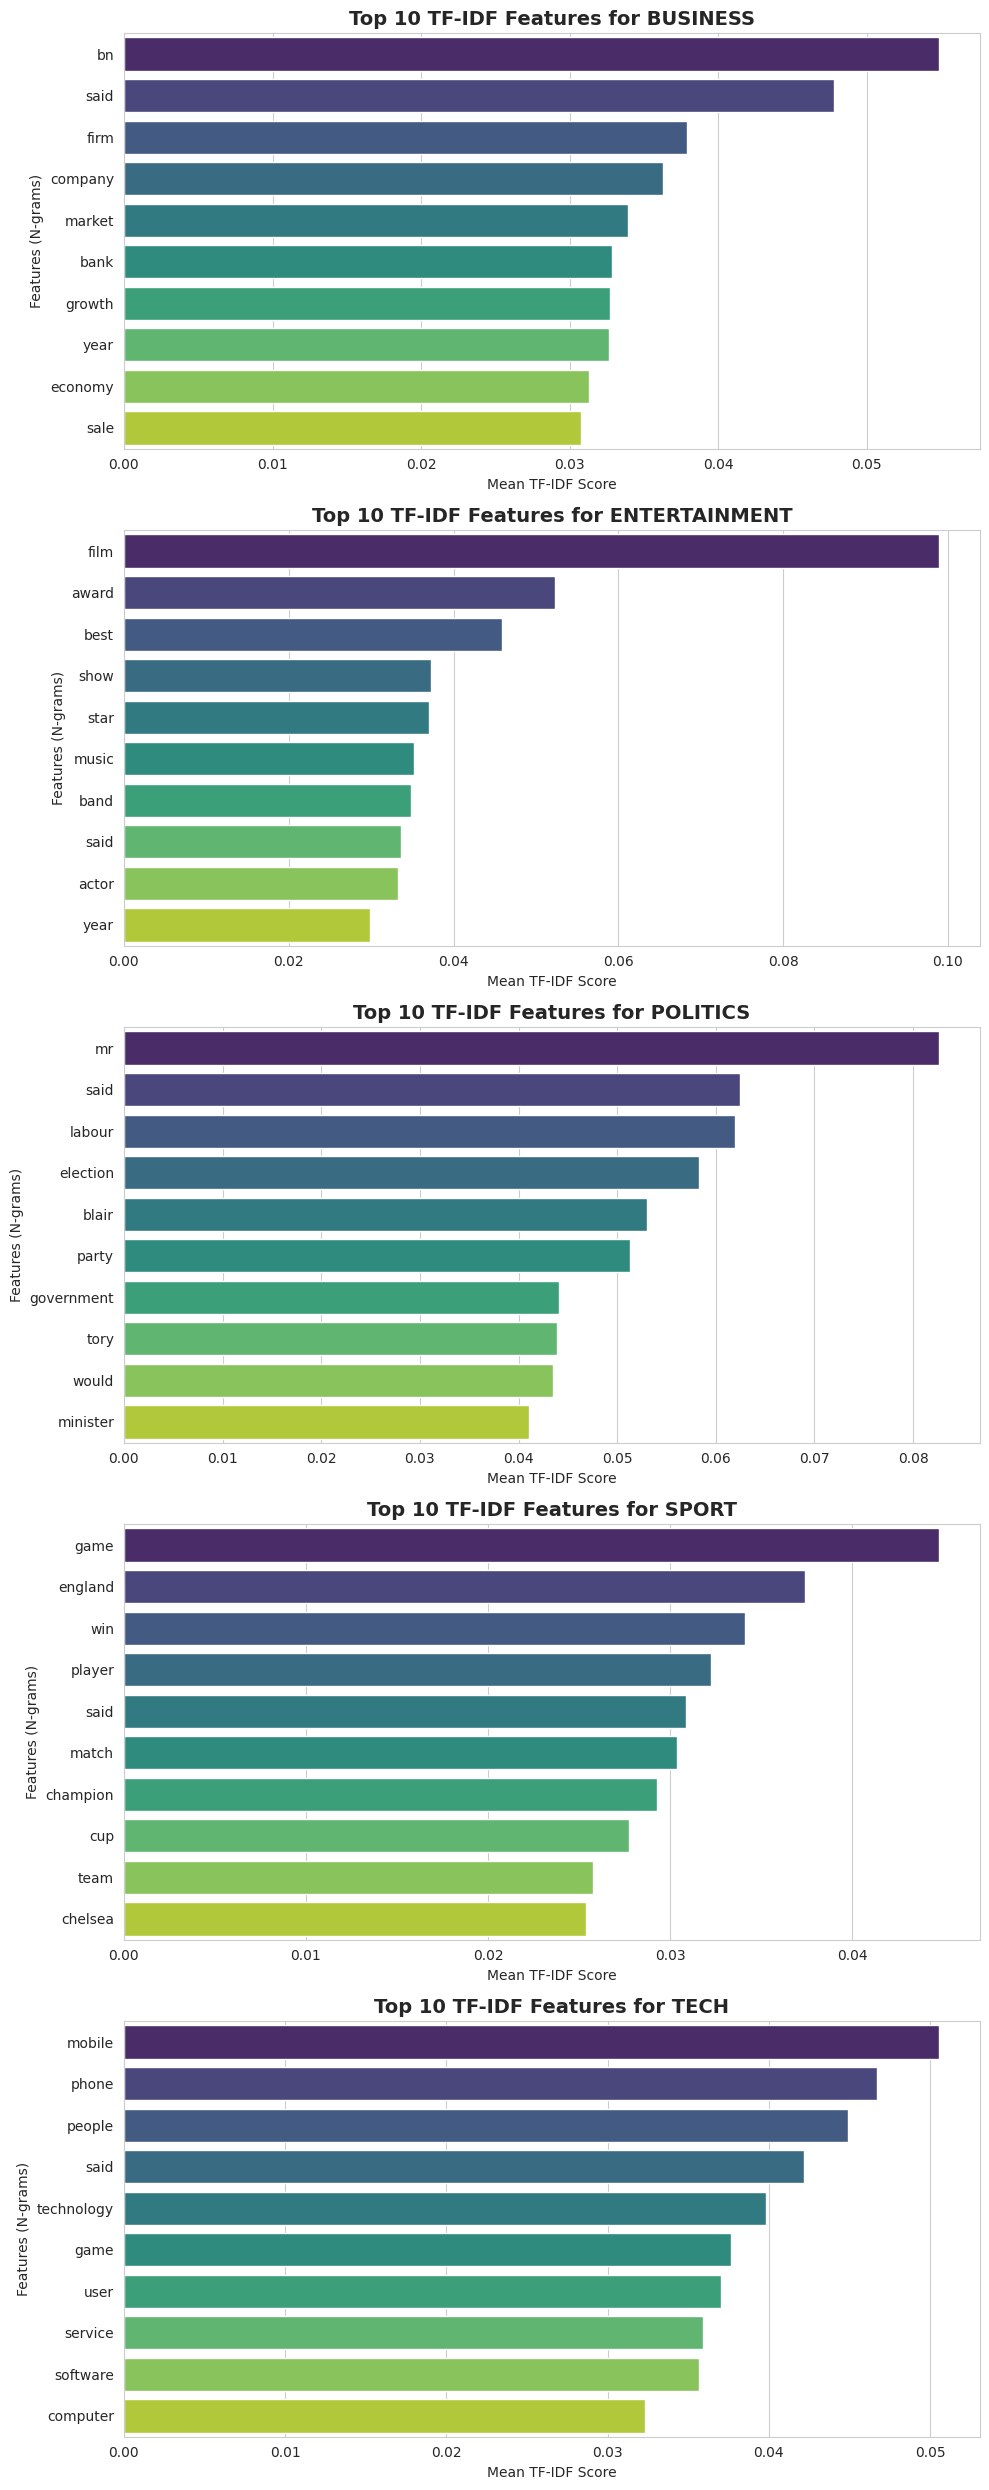

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define categories and prepare plotting
categories = df['Category'].unique()
fig, axes = plt.subplots(len(categories), 1, figsize=(10, 25))
sns.set_style("whitegrid")

def get_top_ngrams(category_name, matrix, features, top_n=10):
    # Filter matrix for the specific category
    cat_indices = df[df['Category'] == category_name].index
    cat_matrix = matrix[cat_indices]

    # Calculate mean TF-IDF scores across the category rows
    mean_weights = np.asarray(cat_matrix.mean(axis=0)).ravel()
    top_indices = mean_weights.argsort()[::-1][:top_n]

    return features[top_indices], mean_weights[top_indices]

# 2. Iterate and plot
for i, cat in enumerate(sorted(categories)):
    top_features, top_scores = get_top_ngrams(cat, tfidf_matrix_ngrams, feature_names_ngrams)

    # Assign y to hue and set legend=False to follow latest seaborn conventions
    sns.barplot(x=top_scores, y=top_features, ax=axes[i], hue=top_features, palette='viridis', legend=False)
    axes[i].set_title(f'Top 10 TF-IDF Features for {cat.upper()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Mean TF-IDF Score')
    axes[i].set_ylabel('Features (N-grams)')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the improvements in feature extraction and how n-gram optimization provides better context for the classification models.


## Summary:

### Q&A

**How do n-gram optimizations provide better domain-specific context for classification models compared to unigrams?**
N-gram optimization, specifically including bigrams ($ngram\_range=(1, 2)$), captures relationships between adjacent words that unigrams alone cannot. For example, the term "award" is generic, but the bigram "academy award" provides immediate context for the Entertainment category. By including these phrases, the model can distinguish between different uses of common words based on their neighbors, leading to a more nuanced and accurate feature set for classification.

### Data Analysis Key Findings

*   **Feature Enrichment:** Updating the `TfidfVectorizer` to include bigrams resulted in **847 bigrams** being identified among the top 5,000 features. This expanded the feature set from simple vocabulary to include specific names and compound terms like "alex ferguson" and "according report."
*   **Dimensionality Management:** By setting `max_features=5000` and `min_df=2`, the process successfully balanced rich contextual data with computational efficiency, filtering out noisy, rare terms that only appeared in a single document.
*   **Category-Specific Indicators:** Visualization of TF-IDF scores confirmed that n-grams act as strong discriminators for BBC news categories:
    *   **Tech/Business:** Captured technical terminology and corporate entities.
    *   **Sport:** Identified specific athlete names and team-related phrases.
    *   **Politics/Entertainment:** Highlighted specific organizations and industry-standard phrases (e.g., "academy award").
*   **Statistical Relevance:** The use of mean TF-IDF scores across categories effectively identified terms that are not just frequent, but unique and representative of specific domains.

### Insights or Next Steps

*   **Model Training:** The next step should be to feed this optimized `tfidf_matrix_ngrams` into classification algorithms (like Random Forest or SVM) to measure the actual improvement in F1-scores compared to a unigram-only model.
*   **Refinement of N-grams:** Since bigrams proved highly relevant, testing a range of $(1, 3)$ might capture even more specific entities (e.g., "federal reserve bank"), though this must be balanced against the risk of increasing the feature space too drastically.
